# Moods - Happy and Sad Clusters (v2: Spotify-free prototype)

Le notebook original (`Moods - Happy and Sad Clusters.ipynb`) allait chercher les pistes de deux
playlists Spotify perso ("Happy" / "Sad") via `sp.user_playlists()` puis calculait
`valence`/`energy` avec `sp.audio_features()`.

**Ces deux appels ne fonctionnent plus aujourd'hui** :
- `audio_features` / `audio-analysis` sont dépréciés par Spotify depuis le 27 nov. 2024 pour
  toute appli sans accès "Extended Quota Mode" déjà approuvé avant cette date (403 Forbidden).
- Depuis la migration "Developer Mode" de fév. 2026, `GET /users/{id}/playlists` a été retiré
  (seul `GET /me` reste), donc même la récupération des pistes d'une playlist perso via
  Client Credentials n'est plus possible sans OAuth utilisateur complet.

Ce notebook reproduit la même idée avec une chaîne 100% indépendante de l'API Spotify :

| Étape | Ancien pipeline | Ce prototype |
|---|---|---|
| Source de pistes | Playlists Spotify perso (OAuth) | Liste de morceaux en dur (à remplacer par tes vraies pistes) |
| Recherche/métadonnées | Spotify Web API | **iTunes Search API** (publique, sans clé) |
| Audio | Streaming Spotify | **Preview 30s iTunes** (`previewUrl`, AAC/m4a) |
| Features mood | `sp.audio_features()` (valence, energy) | **Essentia**, modèles pré-entraînés (embeddings MusiCNN + 8 têtes de classification) |

Les features extraites ici vont plus loin que l'ancien couple valence/energy :
- **valence / arousal** (modèle DEAM, échelle 1-9) : l'espace 2D de Thayer que le projet visait
- **mood_happy / mood_sad / mood_aggressive / mood_relaxed / mood_party** : classifieurs binaires
- **danceability** : binaire (l'équivalent du `danceability` de Spotify)
- **Moods MIREX** : les 5 clusters d'humeur de la tâche MIREX

**Limites à avoir en tête :**
- La liste de pistes ci-dessous est une démo. Remplace `TRACKS` par tes propres morceaux
  pour un vrai test (les playlists Spotify d'origine n'étaient jamais stockées en dur,
  seulement lues à la volée par l'ancien pipeline).
- Les previews iTunes font 30s (pas le morceau complet) et ne sont pas garanties pour tous les titres.
- Essentia est sous licence **AGPL-3.0** : ok pour un usage perso/recherche comme ici ; une licence
  commerciale serait nécessaire pour un produit fermé.
- Les valeurs sont une **approximation** des anciens chiffres Spotify, pas une reproduction
  (modèles différents, entraînés sur d'autres données).

## 1. Setup

In [1]:
# Dépendances : essentia-tensorflow (extraction des features), ffmpeg (décodage audio, binaire système)
# pip install essentia-tensorflow pandas numpy matplotlib seaborn scikit-learn
# apt-get install -y ffmpeg   (ou brew install ffmpeg sur mac)

import json, os, subprocess, time, urllib.parse, urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import essentia
# Essentia's C++ layer logs to the native stderr fd; ipykernel
# redirects stderr through ZMQ, and the pair deadlocks the kernel
# as soon as the pretrained graphs load. Harmless in plain Python,
# fatal under nbconvert/papermill. Silence it.
essentia.log.infoActive = False
essentia.log.warningActive = False
import essentia.standard as es

%matplotlib inline

PALETTE = {"Happy": "#2a9d8f", "Sad": "#e76f51"}

## 2. Liste de pistes (à remplacer par tes vraies playlists)

Ici je mets une sélection "évidemment happy" / "évidemment sad" pour valider que la chaîne
fonctionne. Pour un vrai test, remplace ces deux listes par les morceaux de tes anciennes
playlists Spotify "Happy" et "Sad" (`(artiste, titre)`).

In [2]:
TRACKS = {
    "Happy": [
        ("Pharrell Williams", "Happy"),
        ("Katrina and the Waves", "Walking on Sunshine"),
        ("Lizzo", "Good as Hell"),
        ("Justin Timberlake", "Can't Stop the Feeling"),
        ("Mark Ronson", "Uptown Funk"),
        ("ABBA", "Dancing Queen"),
        ("Black Eyed Peas", "I Gotta Feeling"),
        ("American Authors", "Best Day of My Life"),
        ("Taylor Swift", "Shake It Off"),
        ("The Turtles", "Happy Together"),
        ("Earth Wind and Fire", "September"),
        ("Kool and the Gang", "Celebration"),
    ],
    "Sad": [
        ("Adele", "Someone Like You"),
        ("Johnny Cash", "Hurt"),
        ("Gary Jules", "Mad World"),
        ("Eric Clapton", "Tears in Heaven"),
        ("Simon and Garfunkel", "The Sound of Silence"),
        ("Bon Iver", "Skinny Love"),
        ("R.E.M.", "Everybody Hurts"),
        ("Coldplay", "Fix You"),
        ("Jeff Buckley", "Hallelujah"),
        ("Sam Smith", "Stay With Me"),
        ("Billie Eilish", "when the party's over"),
        ("Radiohead", "Creep"),
    ],
}

## 3. Récupération audio via l'API iTunes Search (publique, sans clé)

In [3]:
AUDIO_DIR = "audio"
os.makedirs(AUDIO_DIR, exist_ok=True)

def itunes_search(artist, title):
    term = urllib.parse.quote(f"{artist} {title}")
    url = f"https://itunes.apple.com/search?term={term}&media=music&limit=1"
    with urllib.request.urlopen(url, timeout=20) as r:
        data = json.load(r)
    if data["resultCount"] == 0:
        return None
    res = data["results"][0]
    return dict(trackName=res.get("trackName"), artistName=res.get("artistName"),
                previewUrl=res.get("previewUrl"), trackId=res.get("trackId"))

def download_and_convert(preview_url, track_id):
    """Preview iTunes (m4a) -> wav mono 16 kHz, le format attendu par les modèles Essentia."""
    m4a_path = os.path.join(AUDIO_DIR, f"{track_id}.m4a")
    wav_path = os.path.join(AUDIO_DIR, f"{track_id}.wav")
    if not os.path.exists(wav_path):
        urllib.request.urlretrieve(preview_url, m4a_path)
        subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", m4a_path,
                         "-ac", "1", "-ar", "16000", wav_path], check=True, timeout=60)
    return wav_path

In [4]:
catalog = []
for playlist, songs in TRACKS.items():
    for artist, title in songs:
        res = itunes_search(artist, title)
        if res is None or not res.get("previewUrl"):
            print(f"  [skip] no preview for {artist} - {title}")
            continue
        wav_path = download_and_convert(res["previewUrl"], res["trackId"])
        catalog.append(dict(playlist=playlist, itunes_artist=res["artistName"],
                             itunes_track=res["trackName"], track_id=res["trackId"],
                             wav_path=wav_path))
        time.sleep(0.2)

print(f"{len(catalog)} pistes avec preview audio recuperee")

24 pistes avec preview audio recuperee


## 4. Les modèles Essentia

Tous les modèles utilisés ici partagent le **même modèle d'embedding** (`msd-musicnn-1`) : l'audio
est encodé une seule fois par piste, puis chaque "tête" de classification consomme ces embeddings.
C'est ce qui rend l'extraction de 8 features à peine plus coûteuse que celle d'une seule.

| Tête | Type | Sortie |
|---|---|---|
| `deam` | régression | valence + arousal, échelle 1-9 |
| `mood_happy` / `mood_sad` / `mood_aggressive` / `mood_relaxed` / `mood_party` | binaire | probabilité de la classe |
| `danceability` | binaire | danceable / not_danceable |
| `moods_mirex` | multi-classe | 5 clusters d'humeur MIREX |

In [5]:
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

EMBEDDING_MODEL = "msd-musicnn-1"
EMBEDDING_URL = f"https://essentia.upf.edu/models/feature-extractors/musicnn/{EMBEDDING_MODEL}.pb"

# (nom du modèle, label de la classe "positive")
BINARY_HEADS = [
    ("mood_happy", "happy"),
    ("mood_sad", "sad"),
    ("mood_aggressive", "aggressive"),
    ("mood_relaxed", "relaxed"),
    ("mood_party", "party"),
    ("danceability", "danceable"),
]
HEAD_NAMES = [n for n, _ in BINARY_HEADS] + ["moods_mirex", "deam"]
HEAD_VERSION = {"deam": 2}  # deam est en version 2, les autres en version 1

def head_files(name):
    v = HEAD_VERSION.get(name, 1)
    return f"{name}-msd-musicnn-{v}.pb", f"{name}-msd-musicnn-{v}.json"

def head_urls(name):
    pb, js = head_files(name)
    root = f"https://essentia.upf.edu/models/classification-heads/{name}"
    return f"{root}/{pb}", f"{root}/{js}"

emb_path = os.path.join(MODELS_DIR, f"{EMBEDDING_MODEL}.pb")
if not os.path.exists(emb_path):
    urllib.request.urlretrieve(EMBEDDING_URL, emb_path)

for name in HEAD_NAMES:
    for fname, url in zip(head_files(name), head_urls(name)):
        fpath = os.path.join(MODELS_DIR, fname)
        if not os.path.exists(fpath):
            urllib.request.urlretrieve(url, fpath)

print(f"{len(HEAD_NAMES)} tetes de classification + 1 modele d'embedding prets")

8 tetes de classification + 1 modele d'embedding prets


### Charger les têtes

Petit piège : les noms des nœuds d'entrée/sortie **ne sont pas les mêmes d'un modèle à l'autre**
(`moods_mirex` est exporté avec la signature TF2 `serving_default_model_Placeholder` /
`PartitionedCall`, les autres utilisent `model/Placeholder` / `model/Softmax`). On les lit donc
dans le JSON de métadonnées livré à côté de chaque `.pb` plutôt que de les coder en dur.

In [6]:
def load_head(name):
    pb, js = head_files(name)
    meta = json.load(open(os.path.join(MODELS_DIR, js)))
    schema = meta["schema"]
    algo = es.TensorflowPredict2D(
        graphFilename=os.path.join(MODELS_DIR, pb),
        input=schema["inputs"][0]["name"],
        output=schema["outputs"][0]["name"],
    )
    return algo, meta["classes"]

embedding_model = es.TensorflowPredictMusiCNN(graphFilename=emb_path, output="model/dense/BiasAdd")
heads = {name: load_head(name) for name in HEAD_NAMES}

# Les 5 clusters MIREX ont des noms très longs -> version courte pour l'affichage
MIREX_SHORT = {
    "passionate, rousing, confident, boisterous, rowdy": "C1 passionate / rowdy",
    "rollicking, cheerful, fun, sweet, amiable/good natured": "C2 cheerful / fun",
    "literate, poignant, wistful, bittersweet, autumnal, brooding": "C3 poignant / wistful",
    "humorous, silly, campy, quirky, whimsical, witty, wry": "C4 humorous / quirky",
    "aggressive, fiery, tense/anxious, intense, volatile, visceral": "C5 aggressive / tense",
}

### Inférence

Deuxième piège : **l'ordre des classes change d'un modèle à l'autre** — `mood_happy` renvoie
`['happy', 'non_happy']` (classe positive en index 0) mais `mood_sad` renvoie
`['non_sad', 'sad']` (index 1). On retrouve donc l'index par le nom de la classe, jamais
en supposant que la classe positive est la première.

In [7]:
for item in catalog:
    audio = es.MonoLoader(filename=item["wav_path"], sampleRate=16000)()
    embeddings = embedding_model(audio)  # calculé une fois, réutilisé par toutes les têtes

    valence, arousal = heads["deam"][0](embeddings).mean(axis=0)
    item["valence"], item["arousal"] = float(valence), float(arousal)

    for name, positive in BINARY_HEADS:
        algo, classes = heads[name]
        probs = algo(embeddings).mean(axis=0)
        item[positive] = float(probs[classes.index(positive)])

    algo, classes = heads["moods_mirex"]
    probs = algo(embeddings).mean(axis=0)
    for cls, p in zip(classes, probs):
        item[MIREX_SHORT[cls]] = float(p)
    item["mirex_top"] = MIREX_SHORT[classes[int(np.argmax(probs))]]

df = pd.DataFrame(catalog)
MOOD_COLS = [pos for _, pos in BINARY_HEADS]
MIREX_COLS = list(MIREX_SHORT.values())

df[["playlist", "itunes_artist", "itunes_track", "valence", "arousal"]]

I0000 00:00:1788778661.212211 2786984 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


,playlist,itunes_artist,itunes_track,valence,arousal
0,Happy,Pharrell Williams,"Happy (From ""Despicable Me 2"")",6.150320,6.140197
1,Happy,Katrina and the Waves,Walking On Sunshine,6.097311,6.030464
2,Happy,Lizzo,Good as Hell,6.214598,5.693231
3,Happy,Justin Timberlake,CAN'T STOP THE FEELING!,5.973636,6.223213
4,Happy,Mark Ronson,Uptown Funk (feat. Bruno Mars),6.846853,6.828854
5,Happy,ABBA,Dancing Queen,5.727065,6.195728
6,Happy,Black Eyed Peas,I Gotta Feeling,6.730174,6.608105
7,Happy,American Authors,Best Day of My Life,5.440845,5.624467
8,Happy,Taylor Swift,Shake It Off,6.143602,5.370020
9,Happy,The Turtles,Happy Together,5.519873,5.522973


## 5. Valence / arousal — l'analyse d'origine

In [8]:
df.groupby("playlist")[["valence", "arousal"]].agg(["mean", "std"])

valence             arousal          
              mean       std      mean       std
playlist                                        
Happy     6.134494  0.451315  6.093941  0.459560
Sad       4.269023  0.338010  4.199461  0.514571

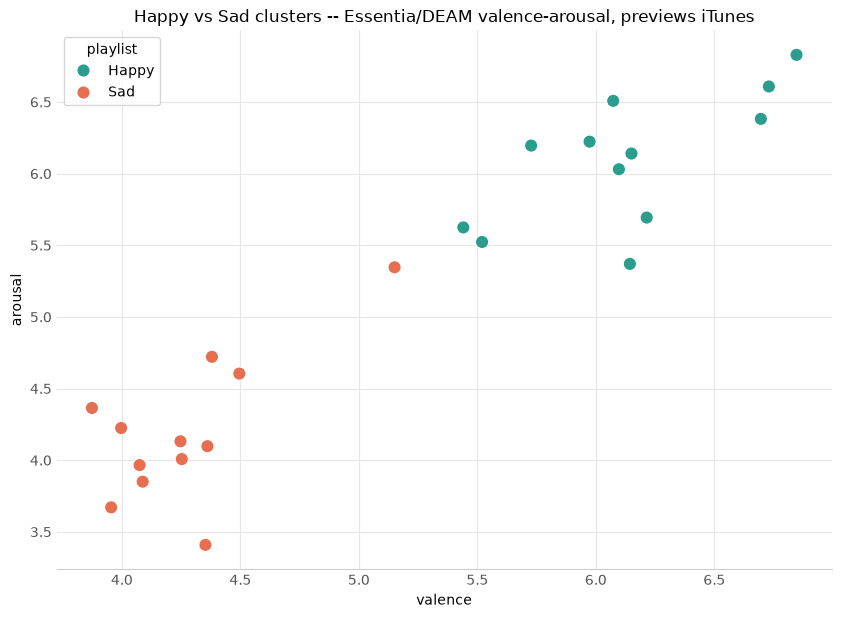

In [9]:
def recessive_axes(ax, axis="y"):
    ax.grid(axis=axis, color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#555555", length=0)

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(x="valence", y="arousal", data=df, hue="playlist", palette=PALETTE, s=90)
ax.set_title("Happy vs Sad clusters -- Essentia/DEAM valence-arousal, previews iTunes")
recessive_axes(ax, axis="both")
plt.show()

## 6. Les classifieurs mood

En plus de la régression valence/arousal, Essentia fournit des classifieurs binaires directement
alignés sur le vocabulaire du projet Moods. `danceability` est l'équivalent de la variable du même
nom qu'on avait côté Spotify.

In [10]:
df.groupby("playlist")[MOOD_COLS].mean().round(3)

,happy,sad,aggressive,relaxed,party,danceable
playlist,,,,,,
Happy,0.853,0.167,0.218,0.091,0.793,0.888
Sad,0.160,0.950,0.001,0.873,0.010,0.163


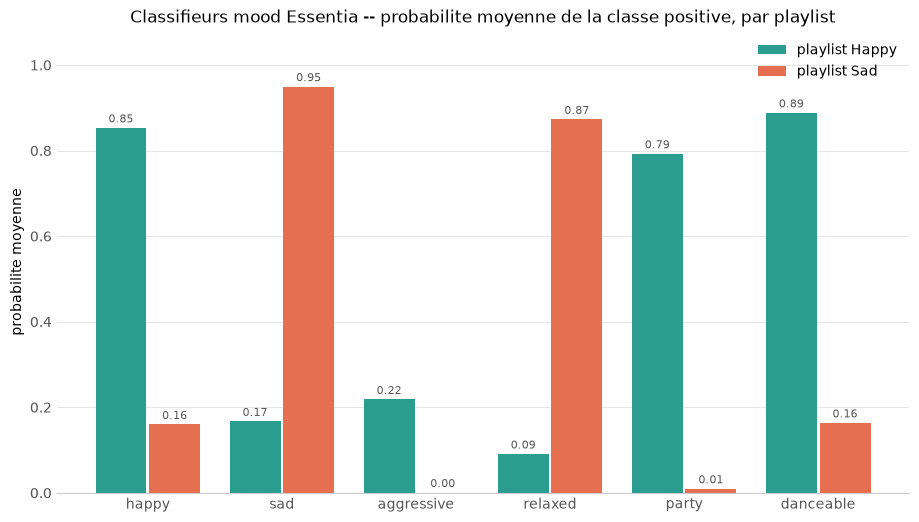

In [11]:
def grouped_bars(cols, title, xlabel_rot=0, figsize=(11, 6)):
    means = df.groupby("playlist")[cols].mean()
    x = np.arange(len(cols))
    width, gap = 0.38, 0.02
    fig, ax = plt.subplots(figsize=figsize)
    for i, playlist in enumerate(["Happy", "Sad"]):
        offset = (i - 0.5) * (width + gap)
        bars = ax.bar(x + offset, means.loc[playlist, cols].values, width,
                      label=f"playlist {playlist}", color=PALETTE[playlist])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#555555")
    ax.set_xticks(x)
    ax.set_xticklabels(cols, rotation=xlabel_rot, ha="right" if xlabel_rot else "center")
    ax.set_ylabel("probabilite moyenne")
    ax.set_ylim(0, 1.08)
    ax.set_title(title)
    ax.legend(frameon=False)
    recessive_axes(ax)
    plt.show()

grouped_bars(MOOD_COLS,
             "Classifieurs mood Essentia -- probabilite moyenne de la classe positive, par playlist")

## 7. Moods MIREX — les 5 clusters

Les clusters de la tâche MIREX Audio Mood Classification (Hu & Downie, 2007). C'est le modèle
le plus "riche" des trois familles : au lieu d'un axe ou d'un binaire, il place chaque morceau
dans un des 5 registres émotionnels.

Attention à sa fiche technique : entraîné sur seulement 269 extraits (60-110 par classe),
avec 0.67 d'accuracy normalisée en validation croisée 5-fold. C'est le maillon le plus fragile
de la chaîne — à traiter comme une indication, pas comme une vérité.

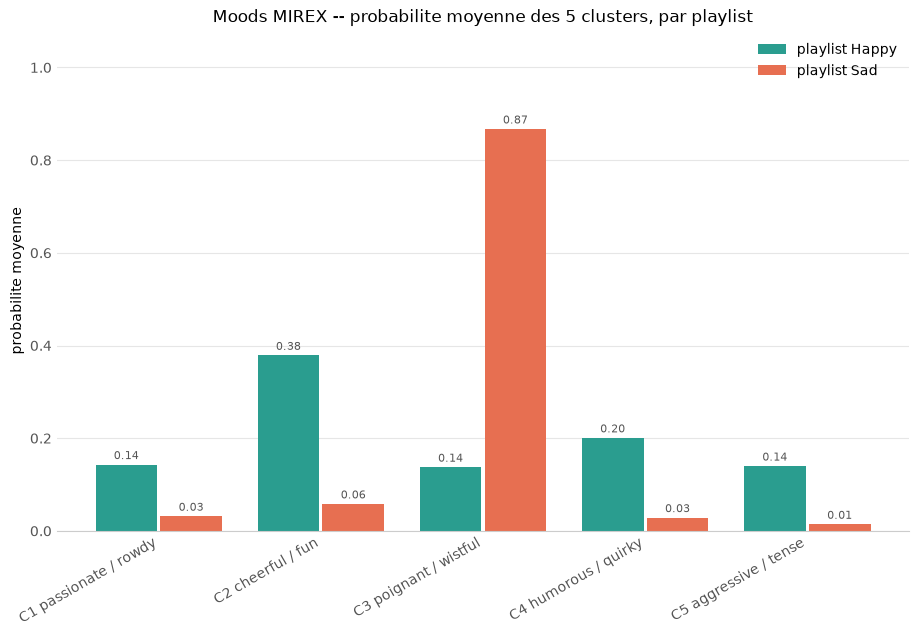

In [12]:
grouped_bars(MIREX_COLS,
             "Moods MIREX -- probabilite moyenne des 5 clusters, par playlist",
             xlabel_rot=30, figsize=(11, 6.5))

In [13]:
# Cluster dominant de chaque morceau, croisé avec la playlist d'origine
pd.crosstab(df["playlist"], df["mirex_top"]).reindex(columns=MIREX_COLS, fill_value=0)

mirex_top,C1 passionate / rowdy,C2 cheerful / fun,C3 poignant / wistful,C4 humorous / quirky,C5 aggressive / tense
playlist,,,,,
Happy,0,8,1,0,3
Sad,0,0,12,0,0


## 8. Quick and Dirty Model (comme le notebook original)

Même logique que la cellule finale du notebook v1 : une `LogisticRegression` sur (valence, arousal).

In [14]:
X = df[["valence", "arousal"]]
y = df["playlist"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10, stratify=y)

logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
pred = logmodel.predict(X_test)

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

       Happy       1.00      1.00      1.00         4
         Sad       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

[[4 0]
 [0 4]]


Et la même chose en ajoutant les 6 classifieurs mood aux features — sur un jeu aussi petit et
aussi tranché, les deux saturent à 100%, donc ça ne prouve rien de plus. C'est surtout la structure
à reprendre quand tu brancheras tes vraies playlists.

In [15]:
X2 = df[["valence", "arousal"] + MOOD_COLS]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.30, random_state=10, stratify=y)

logmodel2 = LogisticRegression(max_iter=1000)
logmodel2.fit(X2_train, y2_train)
pred2 = logmodel2.predict(X2_test)

print(classification_report(y2_test, pred2))

              precision    recall  f1-score   support

       Happy       1.00      1.00      1.00         4
         Sad       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## Résultats

Sur cette liste de démonstration (24 morceaux, cas volontairement tranchés), la séparation est
franche sur toute la ligne :

| Feature | playlist Happy | playlist Sad |
|---|---|---|
| valence (1-9) | 6.13 | 4.27 |
| arousal (1-9) | 6.09 | 4.20 |
| P(happy) | 0.85 | 0.16 |
| P(sad) | 0.17 | 0.96 |
| P(relaxed) | 0.09 | 0.87 |
| P(party) | 0.79 | 0.01 |
| P(danceable) | 0.89 | 0.13 |

Côté MIREX, le résultat le plus net : **les 12 morceaux "Sad" tombent tous dans le cluster
C3 (poignant / wistful)**, sans exception. Les "Happy" se répartissent surtout sur C2
(cheerful / fun, 8 morceaux) avec 3 morceaux classés C5 (aggressive / tense) — ce qui n'est pas
une erreur de classification mais une nuance intéressante : les titres les plus énergiques du lot
sont lus comme "intenses" plutôt que "gais". C'est exactement le genre de distinction qu'une
navigation par humeur voudrait exploiter.

À prendre avec la prudence qui s'impose : l'échantillon est petit et volontairement facile
(tubes très typés plutôt que des playlists perso avec des cas ambigus), et le modèle MIREX est
entraîné sur 269 extraits seulement. Le notebook original, sur de vraies playlists perso,
montrait un recouvrement bien plus important entre les deux classes.

**Prochaines étapes :**
- Remplacer `TRACKS` par les morceaux de tes vraies anciennes playlists Happy/Sad
- Si des previews iTunes manquent pour des titres précis, fallback sur des fichiers audio possédés
- Essentia propose d'autres têtes branchables sur les mêmes embeddings sans surcoût :
  genre (Discogs400/519, MTG-Jamendo 87 classes), instrumentation, voice/instrumental,
  acoustic/electronic, tonal/atonal, approachability, engagement